# Non-Linear

In [181]:
import numpy as np
import matplotlib.pyplot as plt

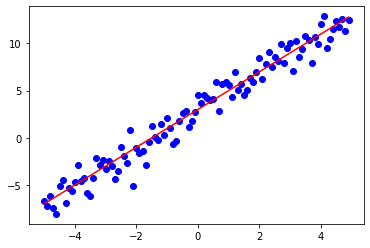

In [182]:
x = np.arange(-5,5,0.1)

y = 2* x + 3
y_noise = np.random.normal(size=x.size)
y_data = y + y_noise
plt.plot(x, y, "r")
plt.scatter(x, y_data, color="blue")
plt.show()

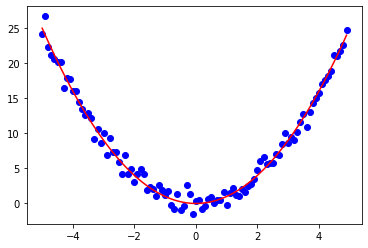

In [183]:
x = np.arange(-5,5,0.1)

y = np.power(x, 2)
y_noise = np.random.normal(size=x.size)
y_data = y + y_noise
plt.plot(x, y, "r")
plt.scatter(x, y_data, color="blue")
plt.show()

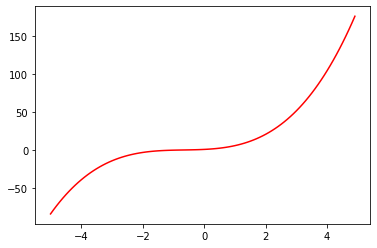

In [184]:
x = np.arange(-5,5,0.1)
y = 1 + 2*x + 2*np.power(x, 2) + np.power(x, 3)
plt.plot(x, y, "r")
plt.show()

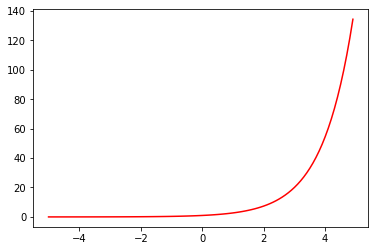

In [185]:
x = np.arange(-5,5,0.1)
y = np.exp(x)
plt.plot(x, y, "r")
plt.show()

/tmp/ipykernel_76002/1491958290.py:2: RuntimeWarning: invalid value encountered in log
  y = np.log(x)


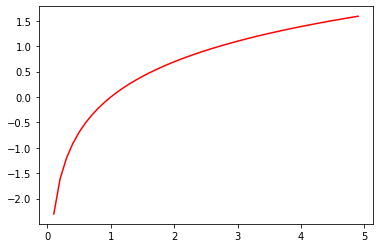

In [186]:
x = np.arange(-5,5,0.1)
y = np.log(x)
plt.plot(x, y, "r")
plt.show()

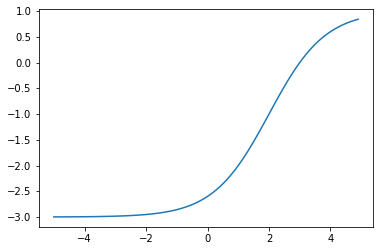

In [187]:
x = np.arange(-5,5,0.1)
y = 1-4/(1+np.power(3,x-2))
plt.plot(x,y)
plt.show()

In [188]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/china_gdp.csv")
df.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


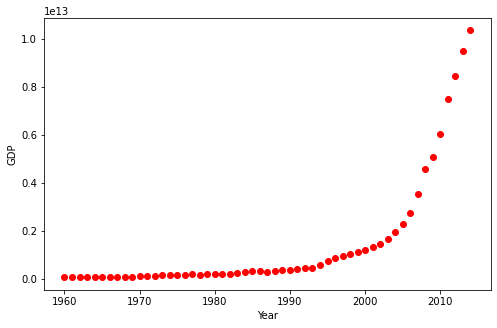

In [189]:
plt.figure(figsize=(8,5))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, "ro")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.show()

In [190]:
def sigmoid(x, Beta_1, Beta_2):
    y= 1/(1+np.exp(-Beta_1*(x-Beta_2)))
    return y

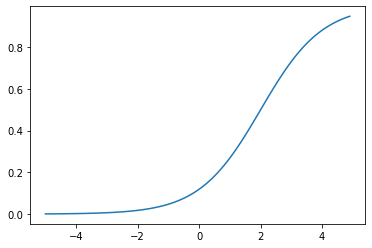

In [191]:
x = np.arange(-5,5,0.1)
y = 1/(1+np.exp(-1*(x-2)))
plt.plot(x,y)
plt.show()

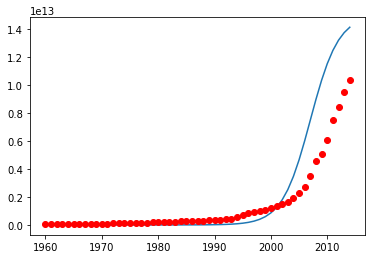

In [192]:
b1 = 0.4
b2 = 2007
y_pred = sigmoid(x_data, b1, b2)
plt.plot(x_data, y_pred*15*np.power(10,12))
plt.plot(x_data,y_data, "ro")
plt.show()

In [193]:
xdata = x_data/max(x_data)
ydata = y_data/max(y_data)

In [194]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(sigmoid, xdata, ydata)
popt

array([690.45171211,   0.99720713])

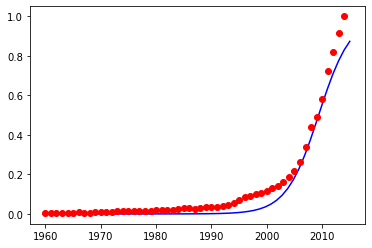

In [195]:
x = np.linspace(1960, 2015, 55)
x_main = x/max(x)
y_main = sigmoid(x_main, *popt)
plt.plot(x_main*max(x), y_main, color="blue")
plt.plot(xdata*max(x_data), ydata, 'ro')
plt.show()

In [197]:
from sklearn.metrics import r2_score
r2 = r2_score(ydata, y_main)
print(r2)

0.9726049983461414


In [196]:
future_year = 2025
future_norm = future_year / max(x_data)

y_pred_norm = sigmoid(future_norm, *popt)
y_pred = y_pred_norm * max(y_data)
y_pred

10320280757939.004